#Quiz 2：Histogram Equalization

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
image = cv2.imread("data/IMG_2.jpg")

In [3]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
V = hsv[:, :, 2]
V

array([[113, 112, 110, ...,   0,   0,   0],
       [118, 119, 117, ...,   0,   0,   0],
       [116, 118, 117, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]],
      shape=(5184, 3456), dtype=uint8)

In [4]:
V_equalized = cv2.equalizeHist(V)
hsv_equalized = hsv.copy()
hsv_equalized[:, :, 2] = V_equalized
result = cv2.cvtColor(hsv_equalized, cv2.COLOR_HSV2BGR)

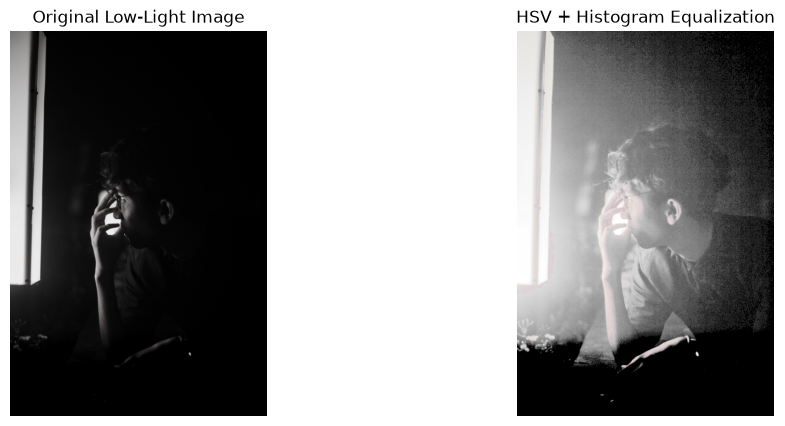

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Low-Light Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("HSV + Histogram Equalization")
plt.axis("off")

plt.show()

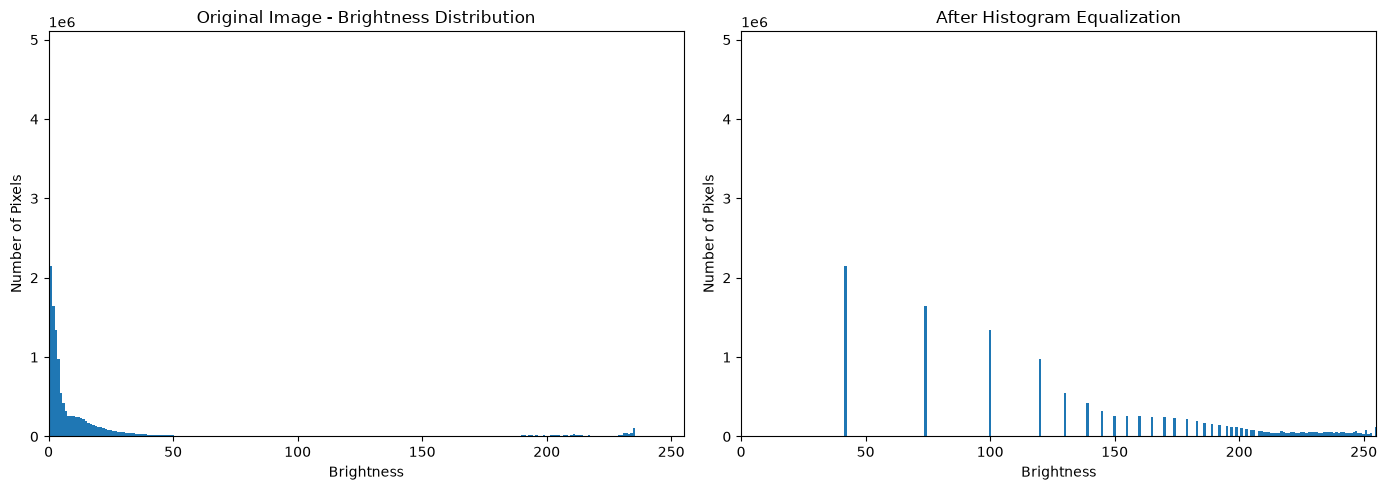

In [6]:
# 計算原始影像與校正後影像的 Histogram
hist_original = np.bincount(V.ravel(), minlength=256)
hist_equalized = np.bincount(V_equalized.ravel(), minlength=256)

# X 軸：亮度 0~255
brightness = np.arange(256)

# 繪製 Histogram
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(brightness, hist_original, width=1)
plt.title("Original Image - Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Number of Pixels")
plt.xlim(0, 255)

plt.subplot(1, 2, 2)
plt.bar(brightness, hist_equalized, width=1)
plt.title("After Histogram Equalization")
plt.xlabel("Brightness")
plt.ylabel("Number of Pixels")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()

#進階使用 NumPy 自行實作演算法,並與 OpenCV 提供的方法進行比較。

In [8]:
hist_test = np.bincount(V.ravel(), minlength=256)
cdf_test = hist_test.cumsum()
hist_test,cdf_test


(array([4862257, 2147148, 1649748, 1346027,  981591,  552494,  428043,
         320814,  255930,  254221,  260566,  251148,  245414,  238644,
         220513,  197511,  176357,  159723,  147645,  136921,  125520,
         114551,  103689,   93248,   83450,   75692,   71174,   66602,
          62081,   57600,   53380,   49060,   45374,   42100,   38689,
          35368,   32231,   29812,   27743,   25722,   24024,   22164,
          20895,   19860,   19076,   18031,   17166,   16275,   14972,
          13913,   13166,   12323,   11574,   10788,   10662,   10235,
           9788,    9383,    8936,    8126,    7494,    6951,    6603,
           6162,    5923,    5691,    5545,    5352,    5139,    5112,
           4961,    4943,    4945,    4835,    4735,    4700,    4674,
           4649,    4691,    4519,    4488,    4412,    4534,    4326,
           4424,    4452,    4329,    4433,    4391,    4205,    4475,
           4331,    4422,    4383,    4314,    4289,    4273,    4152,
      

In [9]:
def histogram_equalization_numpy(V):

    # 1. 計算 Histogram
    hist = np.bincount(V.ravel(), minlength=256)

    # 2. 計算 CDF
    cdf = hist.cumsum()

    # 3. 找第一個非 0 的 CDF
    cdf_nonzero = cdf[cdf > 0]
    cdf_min = cdf_nonzero[0]

    # 4. 建立亮度映射函數
    total_pixels = V.size

    lut = np.round(
        (cdf - cdf_min) * 255 /
        (total_pixels - cdf_min)
    )

    lut = np.clip(lut, 0, 255).astype(np.uint8)

    # 5. 套用亮度映射
    V_equalized = lut[V]

    return V_equalized

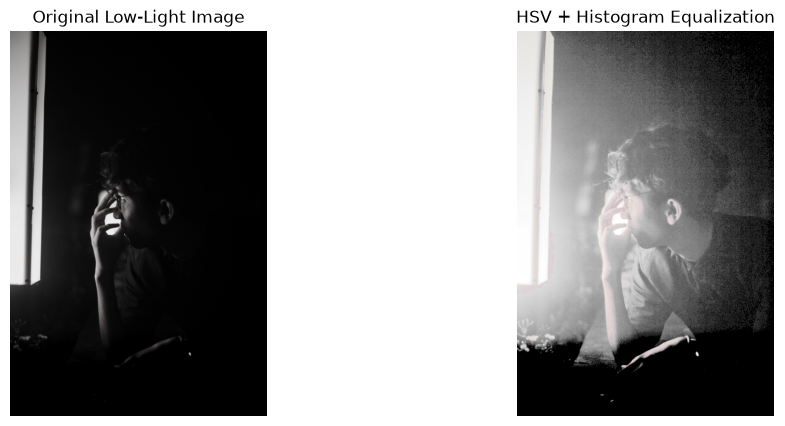

In [11]:
hsv_equalized_np = hsv.copy()
hsv_equalized_np[:, :, 2] = histogram_equalization_numpy(V)
result_np = cv2.cvtColor(hsv_equalized_np, cv2.COLOR_HSV2BGR)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Low-Light Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result_np, cv2.COLOR_BGR2RGB))
plt.title("HSV + Histogram Equalization")
plt.axis("off")

plt.show()

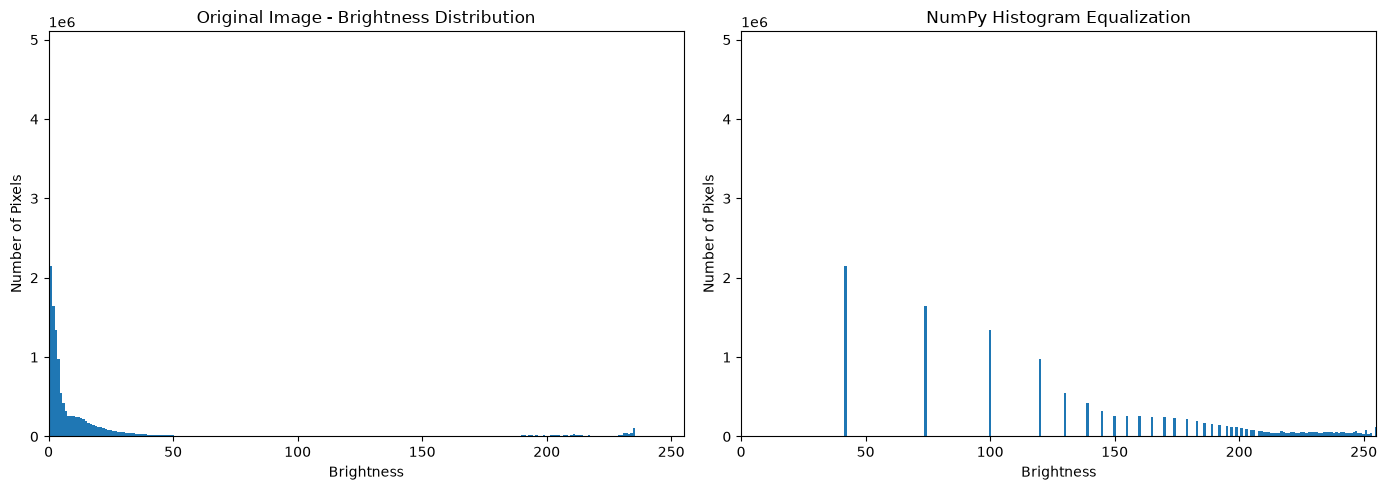

In [12]:
# 原始亮度 Histogram
hist_original = np.bincount(V.ravel(), minlength=256)

# NumPy Histogram Equalization 後的 Histogram
hist_equalized = histogram_equalization_numpy(V)
hist_equalized = np.bincount(V_equalized.ravel(),minlength=256)

# 亮度 0~255
brightness = np.arange(256)

# 畫圖
plt.figure(figsize=(14, 5))

# 原圖
plt.subplot(1, 2, 1)
plt.bar(brightness, hist_original, width=1)
plt.title("Original Image - Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Number of Pixels")
plt.xlim(0, 255)

# NumPy Equalization
plt.subplot(1, 2, 2)
plt.bar(brightness, hist_equalized, width=1)
plt.title("NumPy Histogram Equalization")
plt.xlabel("Brightness")
plt.ylabel("Number of Pixels")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()

1. 重複執行 100 次比較速度

In [13]:
import time

N = 100

# =========================
# OpenCV
# =========================
start = time.perf_counter()

for _ in range(N):
    V_equalized_cv = cv2.equalizeHist(V)

opencv_total = time.perf_counter() - start


# =========================
# NumPy
# =========================
start = time.perf_counter()

for _ in range(N):

    V_equalized_np = histogram_equalization_numpy(V)

numpy_total = time.perf_counter() - start


# =========================
# 顯示結果
# =========================

print("===== 執行速度比較 =====")

print(f"OpenCV 總時間：{opencv_total:.6f} 秒")
print(f"OpenCV 平均時間：{opencv_total / N * 1000:.6f} ms")

print()

print(f"NumPy 總時間：{numpy_total:.6f} 秒")
print(f"NumPy 平均時間：{numpy_total / N * 1000:.6f} ms")

print()

print(f"NumPy / OpenCV：{numpy_total / opencv_total:.2f} 倍")

===== 執行速度比較 =====
OpenCV 總時間：2.358601 秒
OpenCV 平均時間：23.586014 ms

NumPy 總時間：15.373557 秒
NumPy 平均時間：153.735567 ms

NumPy / OpenCV：6.52 倍


2. 比較影像增強效果

In [29]:
print("===== 影像增強效果比較 =====")

print("原始影像")
print(f"亮度最小值：{V.min()}")
print(f"亮度最大值：{V.max()}")
print(f"平均亮度：{V.mean():.2f}")
print(f"亮度標準差：{V.std():.2f}")

print()

print("OpenCV Histogram Equalization")
print(f"亮度最小值：{V_equalized_cv.min()}")
print(f"亮度最大值：{V_equalized_cv.max()}")
print(f"平均亮度：{V_equalized_cv.mean():.2f}")
print(f"亮度標準差：{V_equalized_cv.std():.2f}")

print()

print("NumPy Histogram Equalization")
print(f"亮度最小值：{V_equalized_np.min()}")
print(f"亮度最大值：{V_equalized_np.max()}")
print(f"平均亮度：{V_equalized_np.mean():.2f}")
print(f"亮度標準差：{V_equalized_np.std():.2f}")

===== 影像增強效果比較 =====
原始影像
亮度最小值：0
亮度最大值：244
平均亮度：20.88
亮度標準差：50.91

OpenCV Histogram Equalization
亮度最小值：0
亮度最大值：255
平均亮度：99.06
亮度標準差：82.56

NumPy Histogram Equalization
亮度最小值：0
亮度最大值：255
平均亮度：99.06
亮度標準差：82.56
